In [2]:
import pandas as pd
df = pd.read_csv("Housing.csv")

In [3]:
df.shape

(545, 13)

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
df.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


mainroad:
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64

basement:
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea:
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


C:\Users\SRIDHAR\AppData\Local\Temp\ipykernel_24032\3160286758.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [12]:
# Checking Missing Values

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [13]:
#Checking duplicate rows

df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(545, 13)

In [15]:
# Seperating Features and Target

X = df.drop("price", axis=1)
y = df["price"]

In [16]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [17]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (545, 12)
y shape: (545,)


In [20]:
# Encoding Categorical Columns

categorical_cols = X.select_dtypes(include="object").columns
categorical_cols.tolist()

C:\Users\SRIDHAR\AppData\Local\Temp\ipykernel_24032\2484501172.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [21]:
# Using One-hot Encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [22]:
X_encoded.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [23]:
print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)

Shape before encoding: (545, 12)
Shape after encoding: (545, 13)


In [24]:
#Train and Test Split

from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (436, 13)
X_test: (109, 13)
y_train: (436,)
y_test: (109,)


In [28]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [29]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (436, 13)
X_test_scaled shape: (109, 13)


In [31]:
print("Training mean:", X_train_scaled.mean())
print("Training standard deviation:", X_train_scaled.std())

Training mean: 3.1340099495417265e-17
Training standard deviation: 1.0


In [33]:
# Importing Regression Model

from sklearn.linear_model import LinearRegression
model = LinearRegression()


In [35]:
# Training Model

model.fit(X_train_scaled, y_train)
print("Model training completed successfully.")

Model training completed successfully.


In [36]:
# Making Predictions
y_pred = model.predict(X_test_scaled)

In [37]:
print(y_pred[:10])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.3272256
 3294646.25725956 3532275.09556558 5611774.56836474 6368145.98732718
 2722856.95689986 2629405.61585783]


In [39]:
#Compare actual vs predicted prices
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


In [40]:
# Evaluating Model using RMSE,R^2

from sklearn.metrics import mean_squared_error, r2_score

In [42]:
# Calculate RMSE
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [43]:
# Calculating R^2

r2 = r2_score(y_test, y_pred)

In [44]:
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1324506.9600914402
R² Score: 0.6529242642153176


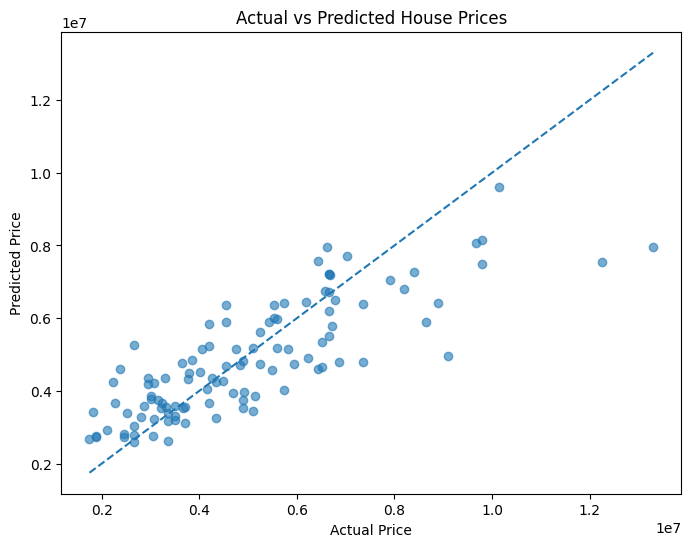

In [46]:
# Actual vs Predicted Price Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [47]:
# Key Features

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
2,bathrooms,521879.027748,521879.027748
0,area,519552.416340,519552.416340
9,airconditioning_yes,365157.393851,365157.393851
3,stories,349251.438906,349251.438906
10,prefarea_yes,266656.351993,266656.351993
12,furnishingstatus_unfurnished,-192015.917982,192015.917982
4,parking,192005.953667,192005.953667
7,basement_yes,187067.803214,187067.803214
8,hotwaterheating_yes,149862.702991,149862.702991
5,mainroad_yes,128498.628215,128498.628215


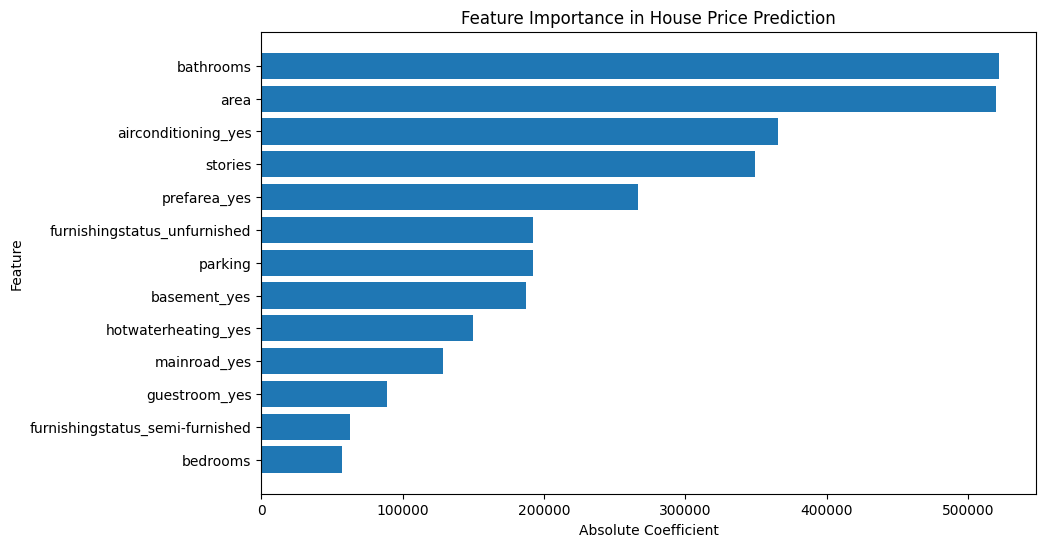

In [48]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Feature Importance in House Price Prediction")
plt.gca().invert_yaxis()

plt.show()

In [49]:
feature_importance[["Feature", "Coefficient"]]

,Feature,Coefficient
2,bathrooms,521879.027748
0,area,519552.416340
9,airconditioning_yes,365157.393851
3,stories,349251.438906
10,prefarea_yes,266656.351993
12,furnishingstatus_unfurnished,-192015.917982
4,parking,192005.953667
7,basement_yes,187067.803214
8,hotwaterheating_yes,149862.702991
5,mainroad_yes,128498.628215


In [50]:
"""
In this trained Linear Regression model, bathrooms and area have the largest positive coefficient magnitudes. Air conditioning, stories, and preferred-area status also contribute substantially. The furnishing-status coefficients are negative relative to the reference furnishing category.
"""

'\nIn this trained Linear Regression model, bathrooms and area have the largest positive coefficient magnitudes. Air conditioning, stories, and preferred-area status also contribute substantially. The furnishing-status coefficients are negative relative to the reference furnishing category.\n'

In [51]:
#Testing the Model with a Sample House
sample_house = X_test.iloc[[0]]
actual_price = y_test.iloc[0]

sample_house_scaled = scaler.transform(sample_house)
predicted_price = model.predict(sample_house_scaled)[0]

print("Actual Price:", actual_price)
print("Predicted Price:", predicted_price)

Actual Price: 4060000
Predicted Price: 5164653.90033967


In [52]:
#Calculate the prediction error
error = predicted_price - actual_price

print("Actual Price:", actual_price)
print("Predicted Price:", predicted_price)
print("Prediction Error:", error)

Actual Price: 4060000
Predicted Price: 5164653.90033967
Prediction Error: 1104653.9003396695


In [53]:
#Final Model Summary
print("===== House Price Prediction Model Summary =====")
print("Model: Linear Regression")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", X_train.shape[1])
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

===== House Price Prediction Model Summary =====
Model: Linear Regression
Training samples: 436
Testing samples: 109
Number of features: 13
RMSE: 1324506.96
R² Score: 0.6529


In [ ]:
### Conclusion:

"""
A Linear Regression model was developed to predict house prices using numerical and categorical features. 
The categorical variables were converted using one-hot encoding, while the features were standardized using StandardScaler. 
The dataset was divided into 80% training and 20% testing data. The model achieved an RMSE of 1,324,506.96 and an R² score of 0.6529 on the test set, indicating that the model explains approximately 65.29% of the variation in house prices. Area, bathrooms, air conditioning, and stories were among the most influential features according to the model coefficients.
"""